In [1]:
from generate_utils import load_GraphModel, load_BiLSTMModel
import torch
import numpy as np
import pickle
from tqdm import tqdm
from GridMLM_tokenizers import CSGridMLMTokenizer
from graph_utils import get_graph_embeddings_from_string_with_model, get_bilstm_embeddings_from_string_with_model, graph_from_string, compare_heterodata

/home/maximos/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = CSGridMLMTokenizer(
    fixed_length=80,
    quantization='4th',
    intertwine_bar_info=True,
    trim_start=False,
    use_pc_roll=True,
    use_full_range_melody=False
)

In [3]:
device_name = 'cuda:0'
device = torch.device(device_name)

graph_model_path = 'saved_models/graph/graph_model.pt'
bilstm_model_path = 'saved_models/bilstm/bilstm_model.pt'

In [4]:
graph_model = load_GraphModel(graph_model_path, device)
bilstm_model = load_BiLSTMModel(bilstm_model_path, device)

In [5]:
graph_model.eval()
bilstm_model.eval()

HarmonyBiLSTM(
  (input_proj): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (attn): Linear(in_features=256, out_features=1, bias=True)
  (output_proj): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
  )
)

In [6]:
datasets = {
    'gjt': {'path': 'data/gjt_test.pkl', 'dataset': None},
    # 'hook': {'path': 'data/hook_test.pkl', 'dataset': None},
    'nott': {'path': 'data/nott_test.pkl', 'dataset': None},
    # 'wiki': {'path': 'data/wiki_test.pkl', 'dataset': None}
}

In [7]:
for k, v in datasets.items():
    print(f'loading {k}')
    with open(v['path'], 'rb') as f:
        d = pickle.load(f)
    v['dataset'] = d

loading gjt
loading nott


In [8]:
graph_embeddings = []
bilstm_embeddings = []
metadata = []

for k,v in datasets.items():
    for i, d in tqdm(enumerate(v['dataset'])):
        g = d['graph_ready_object']
        bar_objects = g.bar_objects
        for bar_start in range(len(bar_objects)-2):
            bar_end = bar_start + 2
            # graph
            g.make_graph_of_segment(bar_start, bar_end)
            z_graph = graph_model(g.segment_graph.to(device))
            graph_embeddings.append(
                z_graph.detach().cpu().numpy()
            )
            # bilstm
            g.make_bilstm_seq_of_segment(bar_start, bar_end)
            segment_bilstm = g.segment_bilstm.unsqueeze(0)
            lengths = torch.tensor(segment_bilstm.shape[1], dtype=int).unsqueeze(0)
            z_bilstm = bilstm_model(segment_bilstm.to(device), lengths.to(device))
            bilstm_embeddings.append(
                z_bilstm.detach().cpu().numpy()
            )
            # make string of chord symbols
            chords_str = f'{k}_{i}_[{bar_start}, {bar_end}]<br>'
            for bar_idx in range(bar_start, bar_end):
                chords_str += 'b_'
                for chord in bar_objects[bar_idx].chord_objects:
                    mel_pcs = [r.tolist() for pcs in chord.melody_pcs for r in pcs]
                    mel_pcs = list( set(mel_pcs) )
                    chords_str += tokenizer.ids_to_tokens[chord.chord_id] + '_@' + str(len(chord.bar_positions)) + \
                                    '_m' + repr(mel_pcs) + '<br>'
            metadata.append({
                'dataset': k,
                'piece_idx': i,
                'bar_start': bar_start,
                'bar_end': bar_end,
                'chords': chords_str
            })

graph_embeddings = np.vstack(graph_embeddings)
bilstm_embeddings = np.vstack(bilstm_embeddings)

28it [00:00, 56.89it/s]
45it [00:00, 77.42it/s]


In [9]:
print(graph_embeddings.shape)
print(bilstm_embeddings.shape)

(1054, 128)
(1054, 128)


In [10]:
print(metadata[100])

{'dataset': 'gjt', 'piece_idx': 7, 'bar_start': 8, 'bar_end': 10, 'chords': 'gjt_7_[8, 10]<br>b_F:maj7_@2_m[0, 9]<br>E:min7_@2_m[9, 11, 4, 7]<br>b_F:maj7_@2_m[9]<br>E:min7_@2_m[9]<br>'}


In [11]:
# in_seq_1 = 'b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]b_D:min_@2_m[2,5,7];G:7_@2_m[5,9,11]'
# in_seq_2 = 'b_C:maj_@2_m[0,4];A:7_@2_m[1,7]b_D:min_@2_m[2,5,9];G:7_@2_m[5,9,2]'
# in_seq_3 = 'b_A:7_@2_m[1,4];D:min_@2_m[2,5,7]b_G:7_@2m[5,9,11];C:maj_@2_m[0,4,9]'
# in_seq_4 = 'b_D:min_@2_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]'

# in_seq_1 = 'b_C:maj_@2_m[0,4,9];A:7_@2_m[1,4]b_D:min_@4_m[2,5,7]'
# in_seq_2 = 'b_C:maj_@2_m[0,4];A:7_@2_m[1,7]b_D:min_@4_m[2,5,9]'
# in_seq_3 = 'b_A:7_@2_m[1,4];D:min_@2_m[2,5,7]b_G:7_@4m[5,9,11]'
# in_seq_4 = 'b_D:min_@0_m[2,5,7];G:7_@2_m[5,9,11]b_C:maj_@0_m[0,4,9]'

# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'
# in_seq_4 = 'b_E:min7_@2_m[2,7];D#:7_@2_m[7]b_G#:maj7_@2_m[7,1];G:7_@2_m[7]'
# in_seq_4 = 'b_A:min_@2_m[7];D#:7_@2_m[7]b_G#:maj7_@2_m[7];G:7_@2_m[7]'

# in_seq_1 = 'b_G:7_@2;C:maj_@2'
# in_seq_2 = 'b_G:9_@2;C:maj_@2'
# in_seq_3 = 'b_B:hdim7_@2;C:maj_@2'
# in_seq_4 = 'b_C#:7_@2;C:maj_@2'

# in_seq_1 = 'b_C:7_@2;F:maj_@2'
# in_seq_2 = 'b_C:9_@2;F:maj_@2'
# in_seq_3 = 'b_E:hdim7_@2;F:maj_@2'
# in_seq_4 = 'b_F#:7_@2;F:maj_@2'

# in_seq_1 = 'b_G:7_@2;C:maj7_@2'
# in_seq_2 = 'b_C:7_@2;F:maj7_@2'
# in_seq_3 = 'b_F:7_@2;A#:maj7_@2'
# in_seq_4 = 'b_A#:7_@2;D#:maj7_@2'

# in_seq_1 = 'b_B:7_@2;E:maj7_@2'
# in_seq_2 = 'b_E:7_@2;A:maj7_@2'
# in_seq_3 = 'b_A:7_@2;D:maj7_@2'
# in_seq_4 = 'b_D:7_@2;G:maj7_@2'

# in_seq_1 = 'b_G:7_@2;C:maj7_@2'
# in_seq_2 = 'b_G:7_@2;D:maj7_@2'
# in_seq_3 = 'b_G:7_@2;A:maj7_@2'
# in_seq_4 = 'b_A#:min11_@4b_A#:min11_@4'

in_seq_1 = 'b_D:7(b9)_@2;G:maj_@2'
in_seq_2 = 'b_D:9_@2;G:maj_@2'
in_seq_3 = 'b_F#:hdim7_@2;G:maj_@2'
in_seq_4 = 'b_G#:7_@2;G:maj_@2'

# in_seq_1 = 'b_C:maj7_@0;F:maj_@2'
# in_seq_2 = 'b_C:maj9_@0;F:maj_@2'
# in_seq_3 = 'b_E:min7_@0;F:maj_@2'
# in_seq_4 = 'b_A:min7_@0;F:maj_@2'

# in_seq_1 = 'b_D:min7_@0;G:7_@2'
# in_seq_2 = 'b_D:min9_@0;G:7_@2'
# in_seq_3 = 'b_F:maj7_@0;G:7_@2'
# in_seq_4 = 'b_A:min7_@0;G:7_@2'

# in_seq_1 = 'b_E:min7_@0;A:7_@2'
# in_seq_2 = 'b_E:min9_@0;A:7_@2'
# in_seq_3 = 'b_G:maj7_@0;A:7_@2'
# in_seq_4 = 'b_B:min7_@0;A:7_@2'

# in_seq_1 = 'b_F#:min7_@0;B:7_@2'
# in_seq_2 = 'b_F#:min9_@0;B:7_@2'
# in_seq_3 = 'b_A:maj7_@0;B:7_@2'
# in_seq_4 = 'b_C#:min7_@0;B:7_@2'

# in_seq_1 = 'b_B:min7_@0;E:7_@2'
# in_seq_2 = 'b_B:min9_@0;E:7_@2'
# in_seq_3 = 'b_D:maj7_@0;E:7_@2'
# in_seq_4 = 'b_F#:min7_@0;E:7_@2'

# in_seq_1 = 'b_B:min7_@0b_E:7_@0'
# in_seq_2 = 'b_B:min9_@0b_E:7_@0'
# in_seq_3 = 'b_D:maj7_@0b_E:7_@0'
# in_seq_4 = 'b_F#:min7_@0b_E:7_@0'

y_graph_1 = get_graph_embeddings_from_string_with_model(in_seq_1, graph_model)
y_graph_2 = get_graph_embeddings_from_string_with_model(in_seq_2, graph_model)
y_graph_3 = get_graph_embeddings_from_string_with_model(in_seq_3, graph_model)
y_graph_4 = get_graph_embeddings_from_string_with_model(in_seq_4, graph_model)

y_bilstm_1 = get_bilstm_embeddings_from_string_with_model(in_seq_1, bilstm_model)
y_bilstm_2 = get_bilstm_embeddings_from_string_with_model(in_seq_2, bilstm_model)
y_bilstm_3 = get_bilstm_embeddings_from_string_with_model(in_seq_3, bilstm_model)
y_bilstm_4 = get_bilstm_embeddings_from_string_with_model(in_seq_4, bilstm_model)

D:7(b9) in vocab as: 90
G:maj in vocab as: 210
D:9 in vocab as: 81
G:maj in vocab as: 210
F#:hdim7 in vocab as: 194
G:maj in vocab as: 210
G#:7 in vocab as: 245
G:maj in vocab as: 210
D:7(b9) in vocab as: 90
G:maj in vocab as: 210
D:9 in vocab as: 81
G:maj in vocab as: 210
F#:hdim7 in vocab as: 194
G:maj in vocab as: 210
G#:7 in vocab as: 245
G:maj in vocab as: 210


In [12]:
from sklearn.decomposition import PCA

In [13]:
pca_graph = PCA(n_components=2)
pca_bilstm = PCA(n_components=2)

In [14]:
y_graph = pca_graph.fit_transform(graph_embeddings)
y_bilstm = pca_bilstm.fit_transform(bilstm_embeddings)

In [15]:
# transform new points
new_graph = np.vstack([
    y_graph_1.detach().cpu().numpy(),
    y_graph_2.detach().cpu().numpy(),
    y_graph_3.detach().cpu().numpy(),
    y_graph_4.detach().cpu().numpy(),
])

new_bilstm = np.vstack([
    y_bilstm_1.detach().cpu().numpy(),
    y_bilstm_2.detach().cpu().numpy(),
    y_bilstm_3.detach().cpu().numpy(),
    y_bilstm_4.detach().cpu().numpy(),
])

new_graph_2d = pca_graph.transform(new_graph)
new_bilstm_2d = pca_bilstm.transform(new_bilstm)

In [16]:
# print(y_graph.shape, y_bilstm.shape)

In [17]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

In [18]:
chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
datasets_list = [metadata[i]['dataset'] for i in range(len(y_graph))]
df_graph = pd.DataFrame({
    'x': y_graph[:,0],
    'y': y_graph[:,1],
    'chords': chords_list,
    'dataset': datasets_list
})
fig = px.scatter(
    data_frame=df_graph,
    x='x',
    y='y',
    color='dataset',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hover_data=['chords'],
)
fig.add_trace(go.Scatter(
    x=new_graph_2d[:, 0],
    y=new_graph_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new graph points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

In [19]:
# chords_list = [metadata[i]['chords'] for i in range(len(y_graph))]
df_bilstm = pd.DataFrame({
    'x': y_bilstm[:,0],
    'y': y_bilstm[:,1],
    'chords': chords_list,
    'dataset': datasets_list
})
fig = px.scatter(
    data_frame=df_bilstm,
    x='x',
    y='y',
    color='dataset',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    hover_data=['chords']
)
fig.add_trace(go.Scatter(
    x=new_bilstm_2d[:, 0],
    y=new_bilstm_2d[:, 1],
    mode='markers+text',
    marker=dict(color='red', size=10, symbol='x'),
    text=['y1', 'y2', 'y3', 'y4'],
    hovertext=[
        in_seq_1.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_2.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_3.replace(';','<br>').replace('b_', '<br>b_'),
        in_seq_4.replace(';','<br>').replace('b_', '<br>b_'),
    ],
    hoverinfo='text',
    textposition='top center',
    name='new bilstm points'
))
fig.show()

# fig = px.scatter(
#     data_frame=df,
#     x='x',
#     y='y',
#     hover_data=['chords']
# )
# fig.show()

In [20]:
d = datasets['gjt']['dataset'][17]
d['graph_ready_object'].make_graph_of_segment(13,15)
d['graph_ready_object'].make_bilstm_seq_of_segment(13,15)

In [21]:
g = graph_from_string(in_seq_4)

G#:7 in vocab as: 245
G:maj in vocab as: 210


In [22]:
d['graph_ready_object'].print_info()
g.print_info()

Number of bars: 16
Segment bar range: [13, 15)
Segment graph features:
HeteroData(
  pitch={ x=[12, 12] },
  event={
    num_nodes=2,
    x=[2, 1],
  },
  (pitch, participates, event)={
    edge_index=[2, 12],
    edge_attr=[12, 5],
  },
  (event, next, event)={
    edge_index=[2, 1],
    edge_attr=[1, 6],
  }
)
Segment graph bars:
Bar 14:
Bar token positions: [66, 67, 68, 69]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A#:min11
Pitch classes: [0, 1, 3, 5, 8, 10]
Root: 10
Chord ID: 314
Bar Positions: [0, 1, 2, 3]
Token Positions: [66, 67, 68, 69]
Graph Features:
tensor([[0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0.]])
BiLSTM Features
tensor([1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0.])
Bar 15:
Bar token positions: [71, 72, 73, 74]
Number of chord objects in bar: 1
Chord object 1:
Chord label: A#:min11
Pitch classes: [0, 1, 3, 5, 8, 10]
Root:

In [23]:
graph_dataset = d['graph_ready_object'].segment_graph
graph_string = g.segment_graph

In [24]:
print(type(graph_dataset))
print(type(graph_string))

<class 'torch_geometric.data.hetero_data.HeteroData'>
<class 'torch_geometric.data.hetero_data.HeteroData'>


In [25]:
print(graph_dataset.node_types, graph_string.node_types)
print(graph_dataset.edge_types, graph_string.edge_types)

print(graph_dataset["event"].num_nodes, graph_string["event"].num_nodes)
print(graph_dataset["pitch","participates","event"].edge_index.shape,
      graph_string["pitch","participates","event"].edge_index.shape)

['pitch', 'event'] ['pitch', 'event']
[('pitch', 'participates', 'event'), ('event', 'next', 'event')] [('pitch', 'participates', 'event'), ('event', 'next', 'event')]
2 2
torch.Size([2, 12]) torch.Size([2, 7])


In [26]:
diffs = compare_heterodata(graph_dataset, graph_string)
print("differences:", diffs)

differences: ["('pitch', 'participates', 'event').edge_attr shape differs: torch.Size([12, 5]) vs torch.Size([7, 5])", "('pitch', 'participates', 'event').edge_index shape differs: torch.Size([2, 12]) vs torch.Size([2, 7])", "('event', 'next', 'event').edge_attr values differ", ' first diff edge_attr at [[0, 0], [0, 1], [0, 2], [0, 3], [0, 4]]']


In [27]:
print(graph_dataset["event"].num_nodes)
print(graph_string["event"].num_nodes)

2
2


In [28]:
print(graph_dataset['event', 'next', 'event'].edge_attr)
print(graph_string['event', 'next', 'event'].edge_attr)

tensor([[1., 1., 1., 0., 0., 0.]])
tensor([[0., 0., 0., 1., 1., 0.]])


In [29]:
with torch.no_grad():
    test_graph_dataset = graph_model(d['graph_ready_object'].segment_graph)
with torch.no_grad():
    test_graph_string = graph_model(g.segment_graph)

In [30]:
with torch.no_grad():
    test_bilstm_dataset = bilstm_model(
        d['graph_ready_object'].segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([d['graph_ready_object'].segment_bilstm.shape[0]]).to(device)
    )
with torch.no_grad():
    test_bilst_string = bilstm_model(
        g.segment_bilstm.unsqueeze(0).to(device),
        torch.tensor([g.segment_bilstm.shape[0]]).to(device)
    )

In [31]:
import matplotlib.pyplot as plt

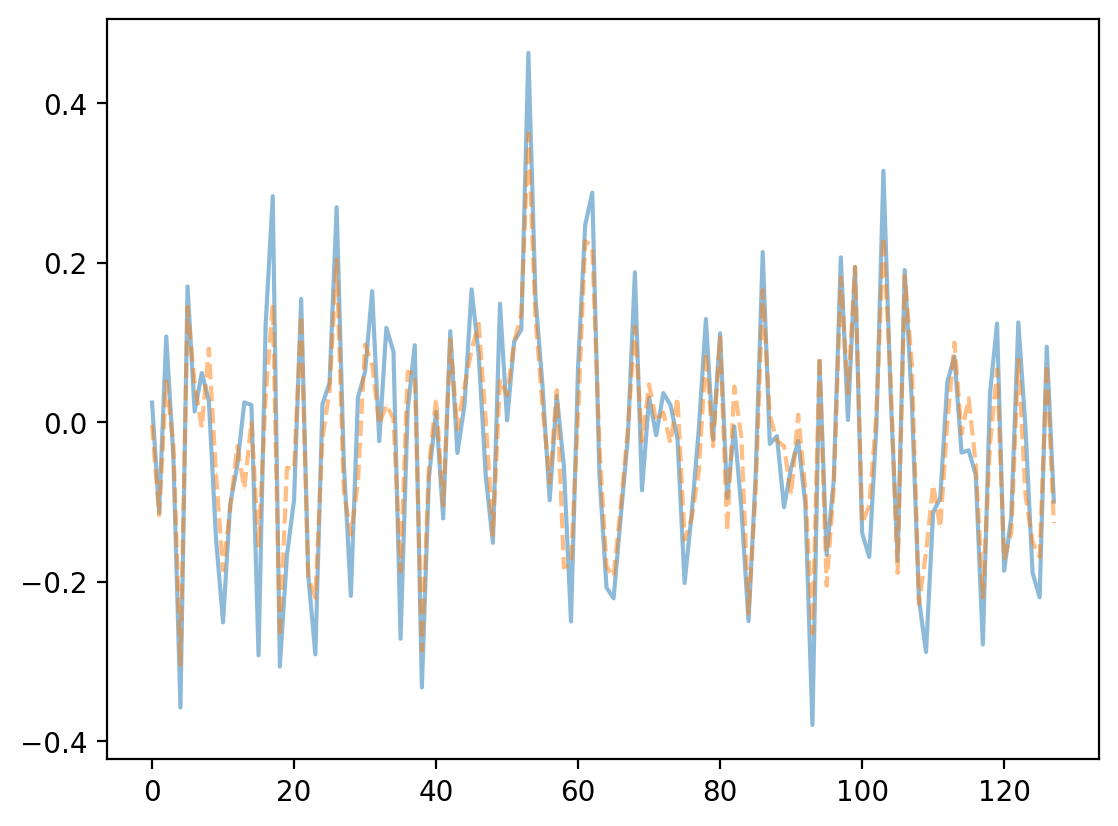

In [32]:
plt.plot(test_graph_dataset.detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_graph_string.detach().cpu().numpy(), '--,', alpha = 0.5)

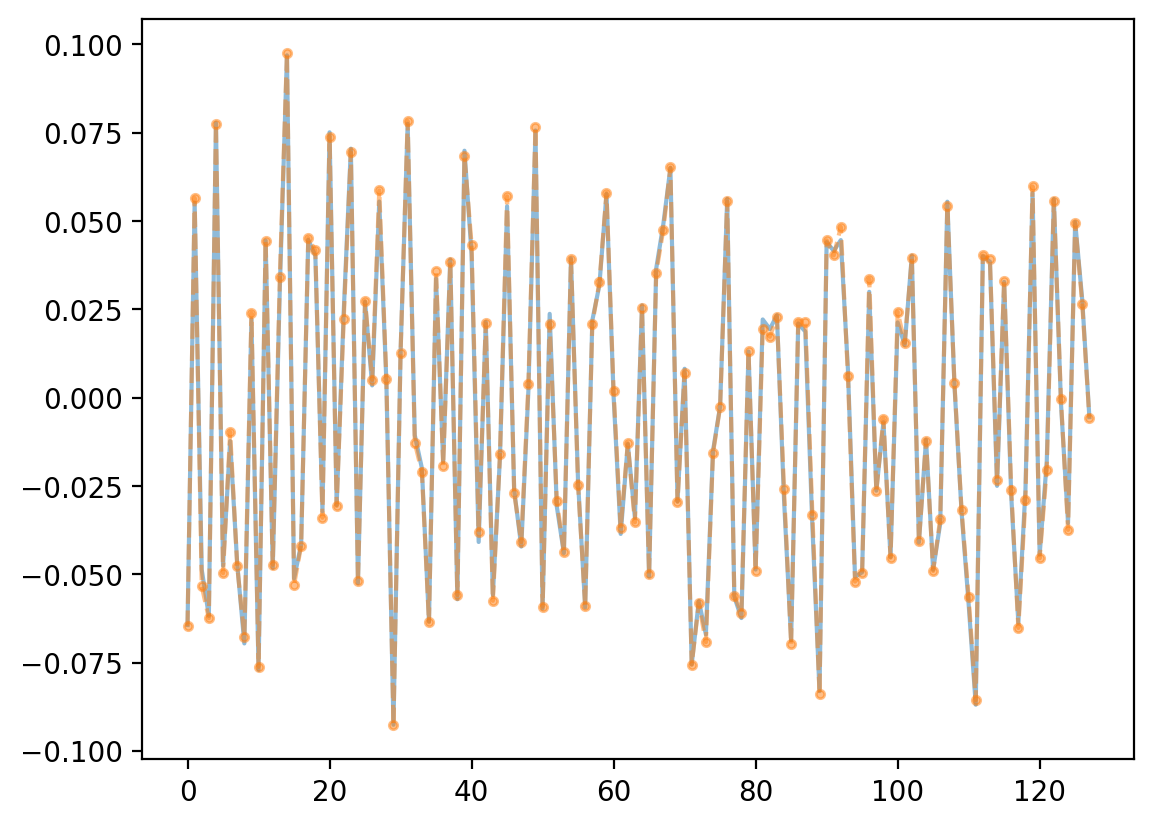

In [33]:
plt.plot(test_bilstm_dataset[0].detach().cpu().numpy(), alpha = 0.5)
plt.plot(test_bilst_string[0].detach().cpu().numpy(), '--.', alpha = 0.5)

In [34]:
print(g.segment_bilstm.shape)
print(d['graph_ready_object'].segment_bilstm.shape)

torch.Size([2, 12])
torch.Size([2, 12])


In [35]:
sorted_x_idxs = np.argsort(y_graph[:,0])
# sorted_x_idxs = np.argsort(y_bilstm[:,0])
print(sorted_x_idxs)
print(chords_list[sorted_x_idxs[0]])
print(chords_list[sorted_x_idxs[-1]])

sorted_y_idxs = np.argsort(y_graph[:,1])
# sorted_y_idxs = np.argsort(y_bilstm[:,1])
print(sorted_y_idxs)
print(chords_list[sorted_y_idxs[0]])
print(chords_list[sorted_y_idxs[-1]])

[923 102 814 ... 240 243 245]
nott_35_[15, 17]<br>b_C:maj_@3_m[0, 4, 7]<br>b_C:maj_@1_m[0]<br>E:min_@2_m[0, 9, 11]<br>
gjt_17_[13, 15]<br>b_A#:min11_@4_m[10]<br>b_A#:min11_@4_m[0]<br>
[913 921 801 ... 235 234 190]
nott_35_[5, 7]<br>b_D:min_@1_m[4, 5]<br>G:7_@2_m[2, 5, 7]<br>b_D:min_@1_m[4, 7]<br>G:7_@2_m[0, 2, 11, 5]<br>
gjt_14_[0, 2]<br>b_G#:7(b13)_@4_m[8, 0, 3]<br>b_G#:7(b13)_@4_m[3, 4, 6]<br>


In [50]:
graph_seqs = ''

# print left-most
print('left-most chord sequences:')
graph_seqs += 'left-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
graph_seqs += '\n'

# print right-most
print('right-most chord sequences:')
graph_seqs += 'right-most chord sequences:' + '\n'
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1
print('')
graph_seqs += '\n'

# print bottom-most
print('bottom-most chord sequences:')
graph_seqs += 'bottom-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
graph_seqs += '\n'

# print top-most
print('top-most chord sequences:')
graph_seqs += 'top-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        graph_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1

left-most chord sequences:
A:min  F:maj7  
A:min  A:min  
F:maj7  F:maj7  
A:min  F:maj  
D:min  A:min  
F:7  F:7  
F:maj  F:maj  
F:7  G#:7  
A:maj  A:min  
A#:maj  F:maj  
A:min  D:min  
G#:7  D:min7  
A:min7  F:maj7  
F:maj  A#:maj  
D#:7  D:min7  
A#:maj7  A#:maj7  
G#:7  G#:7  
D:7  A#:maj  
D:7  G#:7  
C:min7  F:7(#11)  

right-most chord sequences:
A:min7 D:7 G:min7 C:7  F:maj6 B:hdim7 E:7  
G:min7 C:7  A:min7 D:7 G:min7 C:7  
E:maj7 F#:min7 B:sus4  E:maj6 F#:min7 B:7  
C:maj6 B:min7 E:7  C:maj6 A#:min7 D#:7  
E:maj6 F#:min7 B:7  E:maj6 C:min7 F:7  
G:maj6 C:maj6  G:maj6 D:min7 G:7  
C:maj G:7 C:maj  C:maj F:maj  
A:7 D:7  G:7 C:maj7 E:7  
C:maj F:maj  C:maj G:7 C:maj  
G:maj7 D:min7 G:7  C:maj7 F:9  
G:7 C:maj7 E:7  F:maj7 F#:dim7  
G:min7 C:7 C#:dim  D:min7 G:7  
A:min E:maj A:min  A:min E:maj A:min  
A:min7 D:7  G:maj7 D:min7 G:7  
D:min7 G:7(b9)  C:maj6 B:min7 E:7  
A:min7 D:7  G:min7 C:7 C#:dim  
G:min7 C:7 C#:dim  D:min7 A#:maj7  
F#:min7 B:7(b13)  E:maj7 B:min7 E:7  
F:ma

In [51]:
print(graph_seqs)

left-most chord sequences:
A:min  F:maj7  
A:min  A:min  
F:maj7  F:maj7  
A:min  F:maj  
D:min  A:min  
F:7  F:7  
F:maj  F:maj  
F:7  G#:7  
A:maj  A:min  
A#:maj  F:maj  
A:min  D:min  
G#:7  D:min7  
A:min7  F:maj7  
F:maj  A#:maj  
D#:7  D:min7  
A#:maj7  A#:maj7  
G#:7  G#:7  
D:7  A#:maj  
D:7  G#:7  
C:min7  F:7(#11)  

right-most chord sequences:
A:min7 D:7 G:min7 C:7  F:maj6 B:hdim7 E:7  
G:min7 C:7  A:min7 D:7 G:min7 C:7  
E:maj7 F#:min7 B:sus4  E:maj6 F#:min7 B:7  
C:maj6 B:min7 E:7  C:maj6 A#:min7 D#:7  
E:maj6 F#:min7 B:7  E:maj6 C:min7 F:7  
G:maj6 C:maj6  G:maj6 D:min7 G:7  
C:maj G:7 C:maj  C:maj F:maj  
A:7 D:7  G:7 C:maj7 E:7  
C:maj F:maj  C:maj G:7 C:maj  
G:maj7 D:min7 G:7  C:maj7 F:9  
G:7 C:maj7 E:7  F:maj7 F#:dim7  
G:min7 C:7 C#:dim  D:min7 G:7  
A:min E:maj A:min  A:min E:maj A:min  
A:min7 D:7  G:maj7 D:min7 G:7  
D:min7 G:7(b9)  C:maj6 B:min7 E:7  
A:min7 D:7  G:min7 C:7 C#:dim  
G:min7 C:7 C#:dim  D:min7 A#:maj7  
F#:min7 B:7(b13)  E:maj7 B:min7 E:7  
F:ma

In [37]:
# sorted_x_idxs = np.argsort(y_graph[:,0])
sorted_x_idxs = np.argsort(y_bilstm[:,0])
print(sorted_x_idxs)
print(chords_list[sorted_x_idxs[0]])
print(chords_list[sorted_x_idxs[-1]])

# sorted_y_idxs = np.argsort(y_graph[:,1])
sorted_y_idxs = np.argsort(y_bilstm[:,1])
print(sorted_y_idxs)
print(chords_list[sorted_y_idxs[0]])
print(chords_list[sorted_y_idxs[-1]])

[104 468 481 ... 168 210 211]
gjt_7_[12, 14]<br>b_A:min_@4_m[9, 2, 11, 4]<br>b_F:maj7_@4_m[9, 11, 4, 7]<br>
gjt_15_[7, 9]<br>b_A:min7_@1_m[0]<br>D:7_@1_m[0]<br>G:min7_@1_m[0]<br>C:7_@1_m[0]<br>b_F:maj6_@2_m[5]<br>B:hdim7_@1_m[5]<br>E:7_@1_m[4]<br>
[913 921 886 ... 315  39 120]
nott_35_[5, 7]<br>b_D:min_@1_m[4, 5]<br>G:7_@2_m[2, 5, 7]<br>b_D:min_@1_m[4, 7]<br>G:7_@2_m[0, 2, 11, 5]<br>
gjt_9_[0, 2]<br>b_A:min_@2_m[2]<br>A:minmaj7_@2_m[2]<br>b_A:min7_@2_m[0, 2]<br>A:min6_@2_m[0, 9, 11, 7]<br>


In [48]:
bilstm_seqs = ''

# print left-most
print('left-most chord sequences:')
bilstm_seqs += 'left-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
bilstm_seqs += '\n'

# print right-most
print('right-most chord sequences:')
bilstm_seqs += 'right-most chord sequences:' + '\n'
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_x_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1
print('')
bilstm_seqs += '\n'

# print bottom-most
print('bottom-most chord sequences:')
bilstm_seqs += 'bottom-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = 0
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i += 1
print('')
bilstm_seqs += '\n'

# print top-most
print('top-most chord sequences:')
bilstm_seqs += 'top-most chord sequences:' + '\n'
seqs_to_print = 20
printed_seqs = 0
prev_seq = ''
i = -1
while printed_seqs < seqs_to_print:
    pure_seq = ''
    bar_split = chords_list[sorted_y_idxs[i]].split('b_')
    for i_bar in range(1, len(bar_split)):
        semi_split = bar_split[i_bar].split('<br>')
        for semi_part in semi_split:
            at_split = semi_part.split('_@')
            pure_seq += at_split[0] + ' '
    if pure_seq != prev_seq:
        print(pure_seq)
        bilstm_seqs += pure_seq + '\n'
        prev_seq = pure_seq
        printed_seqs += 1
    i -= 1

left-most chord sequences:
A:min  F:maj7  
A:min  A:min  
F:maj7  F:maj7  
A:min  F:maj  
D:min  A:min  
F:7  F:7  
F:maj  F:maj  
F:7  G#:7  
A:maj  A:min  
A#:maj  F:maj  
A:min  D:min  
G#:7  D:min7  
A:min7  F:maj7  
F:maj  A#:maj  
D#:7  D:min7  
A#:maj7  A#:maj7  
G#:7  G#:7  
D:7  A#:maj  
D:7  G#:7  
C:min7  F:7(#11)  

right-most chord sequences:
A:min7 D:7 G:min7 C:7  F:maj6 B:hdim7 E:7  
G:min7 C:7  A:min7 D:7 G:min7 C:7  
E:maj7 F#:min7 B:sus4  E:maj6 F#:min7 B:7  
C:maj6 B:min7 E:7  C:maj6 A#:min7 D#:7  
E:maj6 F#:min7 B:7  E:maj6 C:min7 F:7  
G:maj6 C:maj6  G:maj6 D:min7 G:7  
C:maj G:7 C:maj  C:maj F:maj  
A:7 D:7  G:7 C:maj7 E:7  
C:maj F:maj  C:maj G:7 C:maj  
G:maj7 D:min7 G:7  C:maj7 F:9  
G:7 C:maj7 E:7  F:maj7 F#:dim7  
G:min7 C:7 C#:dim  D:min7 G:7  
A:min E:maj A:min  A:min E:maj A:min  
A:min7 D:7  G:maj7 D:min7 G:7  
D:min7 G:7(b9)  C:maj6 B:min7 E:7  
A:min7 D:7  G:min7 C:7 C#:dim  
G:min7 C:7 C#:dim  D:min7 A#:maj7  
F#:min7 B:7(b13)  E:maj7 B:min7 E:7  
F:ma

In [49]:
print(bilstm_seqs)

left-most chord sequences:
A:min  F:maj7  
A:min  A:min  
F:maj7  F:maj7  
A:min  F:maj  
D:min  A:min  
F:7  F:7  
F:maj  F:maj  
F:7  G#:7  
A:maj  A:min  
A#:maj  F:maj  
A:min  D:min  
G#:7  D:min7  
A:min7  F:maj7  
F:maj  A#:maj  
D#:7  D:min7  
A#:maj7  A#:maj7  
G#:7  G#:7  
D:7  A#:maj  
D:7  G#:7  
C:min7  F:7(#11)  

right-most chord sequences:
A:min7 D:7 G:min7 C:7  F:maj6 B:hdim7 E:7  
G:min7 C:7  A:min7 D:7 G:min7 C:7  
E:maj7 F#:min7 B:sus4  E:maj6 F#:min7 B:7  
C:maj6 B:min7 E:7  C:maj6 A#:min7 D#:7  
E:maj6 F#:min7 B:7  E:maj6 C:min7 F:7  
G:maj6 C:maj6  G:maj6 D:min7 G:7  
C:maj G:7 C:maj  C:maj F:maj  
A:7 D:7  G:7 C:maj7 E:7  
C:maj F:maj  C:maj G:7 C:maj  
G:maj7 D:min7 G:7  C:maj7 F:9  
G:7 C:maj7 E:7  F:maj7 F#:dim7  
G:min7 C:7 C#:dim  D:min7 G:7  
A:min E:maj A:min  A:min E:maj A:min  
A:min7 D:7  G:maj7 D:min7 G:7  
D:min7 G:7(b9)  C:maj6 B:min7 E:7  
A:min7 D:7  G:min7 C:7 C#:dim  
G:min7 C:7 C#:dim  D:min7 A#:maj7  
F#:min7 B:7(b13)  E:maj7 B:min7 E:7  
F:ma

In [40]:
from ollama import chat
from ollama import ChatResponse

response: ChatResponse = chat(model='qwen2.5-coder:7b', messages=[
  {
    'role': 'user',
    'content': 'Can you commend on sequences of musical chords? \
        For example, which chord sequence is more common: a) G:7 C:maj7 or b)C#:7 C:maj7?',
  },
])
print(response['message']['content'])
# or access fields directly from the response object
# print(response.message.content)

Both sequences (a) and (b) involve dominant seventh chords followed by major seventh chords, but they have different root notes. Let's break down each to understand their characteristics:

### Sequence A: G:7 -> C#:maj7

- **G:7** is a dominant seventh chord with the root note G.
  - The chord is built on the scale of G (G, Bb, D, F) and uses the chord tones: G, Bb, D, and F. The seventh degree is typically lowered by a half step to form the dominant function, which in this case is C#.

- **C#:maj7** is a major seventh chord with the root note C#.
  - This chord is built on the scale of C# (C#, Eb, Gb, Bb) and uses the chord tones: C#, Eb, Gb, and Bb. The seventh degree in this case is raised by a half step to form the major function.

### Sequence B: C#:7 -> C:maj7

- **C#:7** is also a dominant seventh chord with the root note C#.
  - Similar to sequence A, the chord is built on the scale of C# (C#, Eb, Gb, Bb) and uses the chord tones: C#, Eb, Gb, and Bb. The seventh degree here is 

In [56]:
response: ChatResponse = chat(model='qwen2.5-coder:7b', messages=[
  {
    'role': 'user',
    'content': f'You are a music harmony expert and you role is to provide \
    comments on chord progressions that appear within two PCA-projected spaces. \
    These PCA spaces were produced by two models that process symbolic music \
    harmony and we are interested in explaining whether there is something \
    specific that the first two axes represent (left-right and bottom-top). \
    These spaces were formed by the same short chord sequences and we only use \
    the ones on the extreme edges in the analysis.\
    We are interested in understanding if Model 1 or Model 2 \
    have generated more musically meaningful representations and which one is better. \
    Keep in mid that both Models are trained on pieces in C major and A minor \
    and that the sequences they processes are segments of C major - A minor pieces. \
    Below are the Sets positioned in the respective PCA spaces by each model. \
    Here is Set 1: `{bilstm_seqs}`. \n\n \
    Here is Set 2: `{graph_seqs}`.\n \
    If you had to pick a model, who would that be and why?',
  },
])
print(response['message']['content'])

The chord progressions in both Set 1 and Set 2 appear to show significant overlap across the PCA-projected spaces. This suggests that while there may be some differences between how Model 1 and Model 2 represent chord progressions, those differences might not be substantial enough to conclude that one is more musically meaningful than the other.

Here’s a breakdown of the observations:

### Left-Most Chord Sequences
- Both sets have similar sequences such as:
  - `A:min  F:maj7`
  - `A:min  A:min`
  - `F:maj7  F:maj7`

This indicates that both models are capturing common chord progressions used in C major and A minor pieces.

### Right-Most Chord Sequences
- Both sets include complex sequences like:
  - `A:min7 D:7 G:min7 C:7  F:maj6 B:hdim7 E:7`
  - `G:min7 C:7  A:min7 D:7 G:min7 C:7`

These are also standard and common in the analyzed music.

### Bottom-Most Chord Sequences
- Both sets feature sequences such as:
  - `D:min G:7  D:min G:7`
  - `G:7  G:7`

These are also typical chord 